In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table
import pandas as pd
from astropy.io import fits
from sklearn.cluster import KMeans
import matplotlib.patheffects as pe

<Table length=196762>
            name              dtype         unit          class     n_bad 
---------------------------- ------- ----------------- ------------ ------
                       kepid   int64                   MaskedColumn      0
                      ra_kic float64               deg       Column      0
                     dec_kic float64               deg       Column      0
                   source_id   int64                   MaskedColumn      0
                random_index   int64                   MaskedColumn      0
                          ra float64               deg       Column      0
                         dec float64               deg       Column      0
                    parallax float64      0.001 arcsec MaskedColumn   1697
              parallax_error float32      0.001 arcsec MaskedColumn   1697
         parallax_over_error float32                   MaskedColumn   1697
                        pmra float64 0.001 arcsec / yr MaskedColumn   1697
   

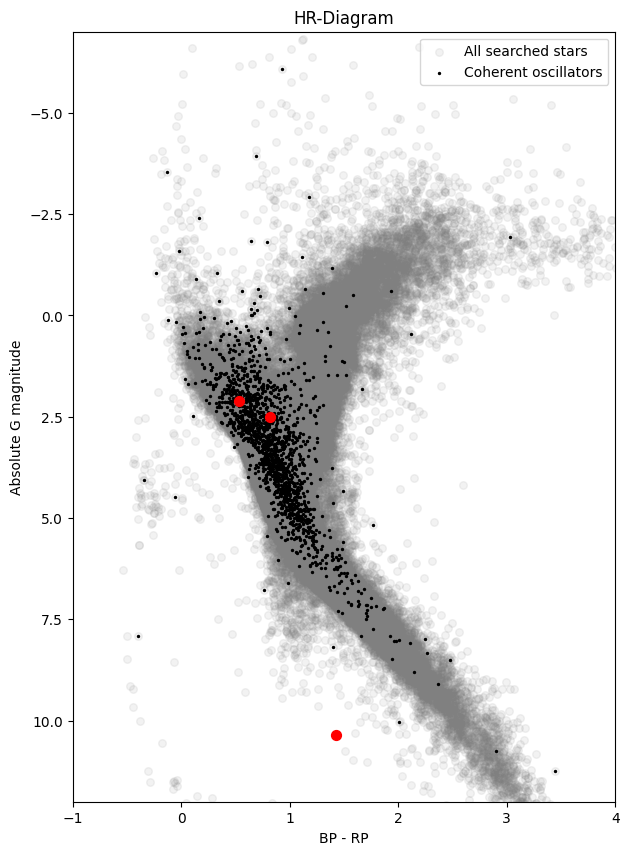

kepid
-----


In [2]:
# Data matching kepler ids to gaia
data = Table.read('kepler_dr3_good.fits', format='fits')
print(data.info())

# All stars searched by nana
df = pd.read_csv('all_KICids.csv')
lines_array = df.to_numpy()[:, 0]
print(lines_array[:10])
searched_kic_ids = [int(s) for s in lines_array]  # remove 'KIC' and convert to int

#All stars with coherent modes
def txt_to_array(filename):
    kic_ids_array = np.zeros(200, dtype = int)
    with open(filename, 'r') as file:
        for i, line in enumerate(file):
            if i >= 200:
                break
            else:   
                print(line.strip()[3:])
                kic_ids_array[i] = int(line.strip()[3:])
        
    return kic_ids_array

def txt_to_array2(filename):
    with open(filename, 'r') as file:
        return np.array([int(line.strip()[3:]) for line in file],dtype=int)


coherent_kic_ids = txt_to_array2("variance_kic_id_list.txt")

mask_valid = data['parallax'] > 0
abs_g = np.full(len(data), np.nan)
abs_g[mask_valid] = (
    data['phot_g_mean_mag'][mask_valid]
    + 5 * np.log10(data['parallax'][mask_valid] / 1000)
    + 5
)
bp_rp = data['bp_rp']

mask_searched = np.isin(data['kepid'], searched_kic_ids)
mask_coherent = np.isin(data['kepid'], coherent_kic_ids)

searched_stars = data[mask_searched]
coherent_oscillators = data[mask_coherent]

abs_g_searched = abs_g[mask_searched]
bp_rp_searched = bp_rp[mask_searched]

abs_g_coherent = abs_g[mask_coherent]
bp_rp_coherent = bp_rp[mask_coherent]


# All stars
#plt.scatter(bp_rp, abs_g, s=5, color='gray', alpha=0.5, label='All stars')

plt.figure(figsize=(7,10))
plt.scatter(bp_rp_searched, abs_g_searched, s=30, color='gray', alpha=0.1, label='All searched stars')
plt.scatter(bp_rp_coherent, abs_g_coherent, s=2, color='black', label='Coherent oscillators')


#PUT KICS FOR POSTER HERE
interesting_kics = np.array([10858720, 6312521, 8330575])
mask_special = np.isin(coherent_oscillators['kepid'], interesting_kics)
plt.scatter(bp_rp_coherent[mask_special], abs_g_coherent[mask_special], s=50, color='red', zorder=5)

plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G magnitude')
plt.title('HR-Diagram')
plt.legend()
plt.xlim(-1, 4)
plt.ylim(12, -7)
plt.savefig('hr_diagram3.png', bbox_inches='tight')
plt.show()

hogg_interests = (bp_rp_coherent > 5) & (abs_g_coherent > 0)

# Get the kepids
hogg_stars = coherent_oscillators['kepid'][hogg_interests]
print(hogg_stars)

In [3]:
with open('coherent_kic_id_list.txt', 'r') as f:
    line_count = sum(1 for line in f)
print(line_count)

264079


In [4]:
def txt_to_array2(filename):
    with open(filename, 'r') as file:
        return np.array([int(line.strip()[3:]) for line in file],dtype=int)

coherent_kic_ids = txt_to_array2("distinct_kic_id_list.txt")

<Table length=196762>
            name              dtype         unit          class     n_bad 
---------------------------- ------- ----------------- ------------ ------
                       kepid   int64                   MaskedColumn      0
                      ra_kic float64               deg       Column      0
                     dec_kic float64               deg       Column      0
                   source_id   int64                   MaskedColumn      0
                random_index   int64                   MaskedColumn      0
                          ra float64               deg       Column      0
                         dec float64               deg       Column      0
                    parallax float64      0.001 arcsec MaskedColumn   1697
              parallax_error float32      0.001 arcsec MaskedColumn   1697
         parallax_over_error float32                   MaskedColumn   1697
                        pmra float64 0.001 arcsec / yr MaskedColumn   1697
   

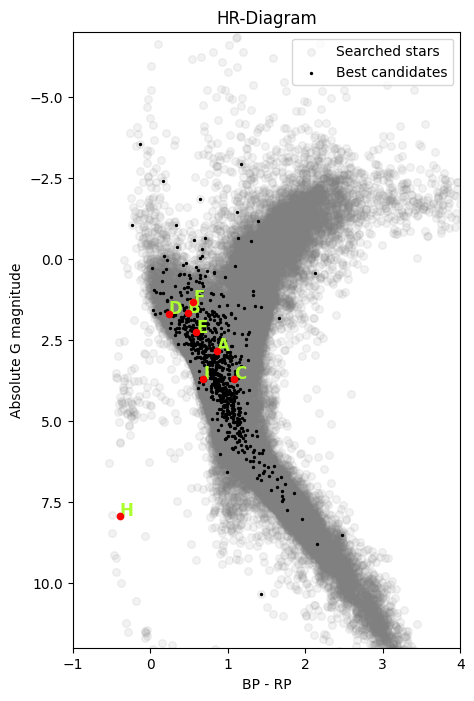

In [21]:
# Data matching kepler ids to gaia
data = Table.read('kepler_dr3_good.fits', format='fits')
print(data.info())

# All stars searched by nana
df = pd.read_csv('all_KICids.csv')
lines_array = df.to_numpy()[:, 0]
print(lines_array[:10])
searched_kic_ids = [int(s) for s in lines_array]  # remove 'KIC' and convert to int

#All stars with coherent modes
def txt_to_array(filename):
    kic_ids_array = np.zeros(200, dtype = int)
    with open(filename, 'r') as file:
        for i, line in enumerate(file):
            if i >= 200:
                break
            else:   
                print(line.strip()[3:])
                kic_ids_array[i] = int(line.strip()[3:])
        
    return kic_ids_array

def txt_to_array2(filename):
    with open(filename, 'r') as file:
        return np.array([int(line.strip()[3:]) for line in file],dtype=int)


#coherent_kic_ids = txt_to_array2("variance_kic_id_list.txt")
coherent_kic_ids = txt_to_array2("star_ids_2026_06.txt")


mask_valid = data['parallax'] > 0
abs_g = np.full(len(data), np.nan)
abs_g[mask_valid] = (
    data['phot_g_mean_mag'][mask_valid]
    + 5 * np.log10(data['parallax'][mask_valid] / 1000)
    + 5
)
bp_rp = data['bp_rp']

mask_searched = np.isin(data['kepid'], searched_kic_ids)
mask_coherent = np.isin(data['kepid'], coherent_kic_ids)

searched_stars = data[mask_searched]
coherent_oscillators = data[mask_coherent]

abs_g_searched = abs_g[mask_searched]
bp_rp_searched = bp_rp[mask_searched]

abs_g_coherent = abs_g[mask_coherent]
bp_rp_coherent = bp_rp[mask_coherent]


# All stars
#plt.scatter(bp_rp, abs_g, s=5, color='gray', alpha=0.5, label='All stars')

plt.figure(figsize=(5,8))
plt.scatter(bp_rp_searched, abs_g_searched, s=30, color='gray', alpha=0.1, label='Searched stars')
plt.scatter(bp_rp_coherent, abs_g_coherent, s=2, color='black', label='Best candidates')

interesting_kics = np.array([3352751, 8166095, 6219684, 8145477, 8196180, 5218385, 1026032, 11234677, 8490027])
mask_special = np.isin(coherent_oscillators['kepid'], interesting_kics)
plt.scatter(bp_rp_coherent[mask_special], abs_g_coherent[mask_special], s=20, color='red', zorder=5)

labels_abc = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
x_special = bp_rp_coherent[mask_special]
y_special = abs_g_coherent[mask_special]
for x, y, label in zip(x_special, y_special, labels_abc):
    plt.annotate(label, (x, y), fontsize=12, color='greenyellow', weight = 'bold')

plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G magnitude')
plt.title('HR-Diagram')
plt.legend()
plt.xlim(-1, 4)
plt.ylim(12, -7)
plt.savefig('hr_diagram3.png', bbox_inches='tight')
plt.show()

In [22]:
##txt file from the fits file

fn = "/Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits"
with fits.open(fn) as hdu_list:
    data = hdu_list[1].data

star_ids = [s.strip() for s in data['star_id']]
np.savetxt('star_ids_2026_06.txt', star_ids, fmt='%s')

## correct formatting for hr diagram

In [23]:
fn = "/Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits"
with fits.open(fn) as hdu_list:
    print(hdu_list.info())
    data = hdu_list[1].data
    header = hdu_list[1].header
print(len(data), header)

Filename: /Users/natsuki/Projects/hogg_research/hoggnation/oscillator_catalog/good_parents_fit.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     21   1438R x 6C   [K, 12A, D, D, K, 65D]   
None
1438 XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                  564 / length of dimension 1                          NAXIS2  =                 1438 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    6 / number of table fields                         TTYPE1  = 'parent_mode_id'                              

In [24]:
features = data["features"]
print(features.shape)
kics = data["star_id"]
print(kics.shape)

#create the time invariant feature vector for clustering (log(a0^2), log(a1^2 + b1^2), ...)
squared_feats = np.zeros((1438, 33))
for e,f in enumerate(features):
    j = 0
    for i in range(len(f) - 1):
        if i == 0:
            squared_feats[e][j] = f[i]**2
            j = j + 1
        if i%2 == 1:
            squared_feats[e][j] = f[i]**2 + f[i+1]**2
            j = j + 1

foo, k = squared_feats.shape
print(squared_feats.shape)
frequencies = np.outer(data["refined_frequency"], (1. + np.arange(k)))
informations = np.nansum(squared_feats * frequencies * (frequencies < 24.), axis=1)
print(informations)


refined_freqs = data["refined_frequency"]
good_mask = ~np.any(np.isnan(squared_feats), axis=1)
print("good mask", good_mask.shape)
print("squared feats before", squared_feats.shape)
squared_feats = squared_feats[good_mask]

print(squared_feats.shape)
log_squared_feats = np.log10(squared_feats)
log_squared_feats = log_squared_feats[:, 1:] #get rid of constant?

#syms = ["o", "X", "s", "D", "+", "*", "p", "^", "d"]
sizes = [3, 7, 11, 15, 18, 21]
sizes2 = [13,18,23,28]
sizes3 = [7, 11, 15, 17]
symbols = ["o", "^", "s", "p", "P", "*", "X", "D", "d"]

kics = kics[good_mask]
refined_freqs = refined_freqs[good_mask]
features = features[good_mask]
print(kics.shape, refined_freqs.shape)

print(np.all(squared_feats))

print(np.sum(squared_feats == 0))        # exact zeros
print(np.sum(squared_feats < 1e-300))    # near-zero values that log10 explodes
print(np.min(squared_feats))             # what is the smallest value?

print(log_squared_feats[:10])

(1438, 65)
(1438,)
(1438, 33)
[2.36271515 3.29346386 0.95380099 ... 0.17196446 2.98164831 2.24898084]
good mask (1438,)
squared feats before (1438, 33)
(1430, 33)
(1430,) (1430,)
True
0
0
4.3329930832059203e-16
[[ -4.67354845  -3.18442387  -6.48298519  -8.50258241  -9.58866259
   -9.15740317  -9.39951717  -9.07418852  -9.46948089  -9.92513252
   -9.04224779  -9.53959707  -8.65462457  -8.79391515  -8.7489132
   -8.01067752  -8.44367284  -7.22553297  -6.55787488  -6.10504669
   -4.65758304  -6.84907928  -7.32206668  -7.97787201  -7.61926582
   -9.30636563  -8.29785074  -7.7150591   -7.99899419  -7.86059726
   -8.41894968  -8.78587244]
 [ -7.41127242 -11.09987381 -11.48368776 -11.43422576 -13.00821719
  -11.59040706 -11.37244909 -12.24747304 -11.45746845 -11.34164738
  -10.64888413 -10.90042432 -10.02199623  -7.11374967  -4.10002514
   -8.67778869  -9.74021949 -10.25812854 -10.99984152 -10.30891953
  -10.69606826 -10.27853494 -10.22754231 -10.01309645 -10.09279598
  -10.15198548 -10.76962

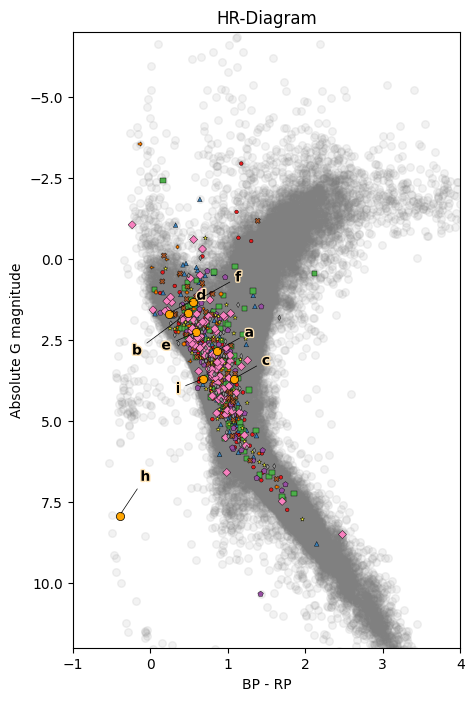

In [25]:
# --- run kmeans first as before ---
K = 9
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=82)
kmeans.fit(log_squared_feats)
labels = kmeans.labels_

# you need a mapping from kic_id -> cluster label
# assuming you have an array of kic_ids corresponding to log_squared_feats rows
# e.g. coherent_kic_ids is already in the same order as log_squared_feats
cluster_lookup = dict(zip(coherent_kic_ids, labels))

# --- HR diagram ---
plt.figure(figsize=(5, 8))
plt.scatter(bp_rp_searched, abs_g_searched, s=30, color='gray', alpha=0.1, label='Searched stars')

# plot coherent oscillators colored by cluster
for group in range(K):
    sym = symbols[group % len(symbols)]
    size = sizes3[group % len(sizes3)]
    
    # get kic_ids in this cluster that are also in the HR data
    group_kics = np.array([kic for kic, lab in cluster_lookup.items() if lab == group])
    mask_group = np.isin(coherent_oscillators['kepid'], group_kics)
    
    plt.scatter(
        bp_rp_coherent[mask_group],
        abs_g_coherent[mask_group],
        c=[group] * mask_group.sum(),
        vmin=0, vmax=8,
        marker=sym,
        s=size,
        cmap='Set1',
        linewidths=0.3,
        edgecolors='black',
        zorder=4
    )

# special red stars on top
mask_special = np.isin(coherent_oscillators['kepid'], interesting_kics)
plt.scatter(bp_rp_coherent[mask_special], abs_g_coherent[mask_special], s=35, color='orange', zorder=5, edgecolors='black', linewidths=0.5)

labels_abc = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']
offsets = [(20, 10), (-40, -30), (20, 10), (20, 10), (-25, -25/2), (30, 15), (25, 15), (15, 25), (-20, -10)]


x_special = bp_rp_coherent[mask_special]
y_special = abs_g_coherent[mask_special]

for x, y, label, offset in zip(x_special, y_special, labels_abc, offsets):
    plt.annotate(label, (x, y), 
                 xytext=offset, textcoords='offset points',
                 fontsize=10, color='black', weight='bold', zorder=10,
                 path_effects=[pe.withStroke(linewidth=2, foreground='moccasin')],
                 arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G magnitude')
plt.title('HR-Diagram')
plt.xlim(-1, 4)
plt.ylim(12, -7)
plt.savefig('hr_diagram_clusters.png', bbox_inches='tight')
plt.show()

In [26]:
mask_blue = (abs_g_coherent > 10)
blue_kics = coherent_oscillators['kepid'][mask_blue]
print(blue_kics)

 kepid 
-------
6312521


## getting rid of orange and putting respective symbol, but where is g? adding outlier instead of group 1

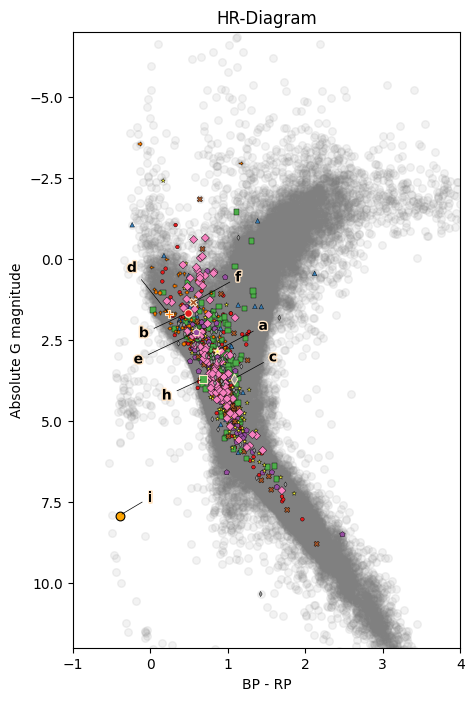

In [67]:
# --- run kmeans first as before ---
K = 9
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=82)
kmeans.fit(log_squared_feats)
labels = kmeans.labels_
cluster_lookup = {int(s.strip()[3:]): lab for s, lab in zip(kics, labels)}

outlier_kic = 8490027
interesting_kics = np.array([3352751, 8166095, 6219684, 8145477, 8196180, 5218385, 1026032, 11234677])  # update this to your 8 non-outlier special kics

# --- HR diagram ---
plt.figure(figsize=(5, 8))
plt.scatter(bp_rp_searched, abs_g_searched, s=30, color='gray', alpha=0.1, label='Searched stars')

# plot coherent oscillators colored by cluster
for group in range(K):
    sym = symbols[group % len(symbols)]
    size = sizes3[group % len(sizes3)]
    group_kics = np.array([kic for kic, lab in cluster_lookup.items() if lab == group])
    mask_group = np.isin(coherent_oscillators['kepid'], group_kics)
    plt.scatter(
        bp_rp_coherent[mask_group],
        abs_g_coherent[mask_group],
        c=[group] * mask_group.sum(),
        vmin=0, vmax=8,
        marker=sym,
        s=size,
        cmap='Set1',
        linewidths=0.3,
        edgecolors='black',
        zorder=4
    )

# special stars on top
mask_special = np.isin(coherent_oscillators['kepid'], interesting_kics)
labels_abc = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
offsets = [(30, 15), (-35, -35/2), (25, 25/2), (-30, 30), (-45, -45/2), (30, 15), (25, 15), (-30, -15)]
x_special = bp_rp_coherent[mask_special]
y_special = abs_g_coherent[mask_special]
special_kics = coherent_oscillators['kepid'][mask_special]

for x, y, label, offset, kic in zip(x_special, y_special, labels_abc, offsets, special_kics):
    group = cluster_lookup.get(kic, 0)
    sym = symbols[group % len(symbols)]
    size = sizes3[group % len(sizes3)]
    plt.scatter(x, y, c=[group], vmin=0, vmax=8, cmap='Set1',
                marker=sym, s=30,
                linewidths=0.8, edgecolors='bisque', zorder=5)
    plt.annotate(label, (x, y),
                 xytext=offset, textcoords='offset points',
                 fontsize=10, color='black', weight='bold', zorder=10,
                 path_effects=[pe.withStroke(linewidth=2, foreground='bisque')],
                 arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# outlier star as orange dot
mask_outlier = coherent_oscillators['kepid'] == outlier_kic
plt.scatter(bp_rp_coherent[mask_outlier], abs_g_coherent[mask_outlier],
            s=40, color='orange', edgecolors='black', linewidths=0.8, zorder=6)
plt.annotate('i', (bp_rp_coherent[mask_outlier][0], abs_g_coherent[mask_outlier][0]),
             xytext=(20, 10), textcoords='offset points',
             fontsize=10, color='black', weight='bold', zorder=10,
             path_effects=[pe.withStroke(linewidth=2, foreground='bisque')],
             arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G magnitude')
plt.title('HR-Diagram')
plt.xlim(-1, 4)
plt.ylim(12, -7)
plt.savefig('hr_diagram_clusters.png', bbox_inches='tight')
plt.show()

## poster version here!!!

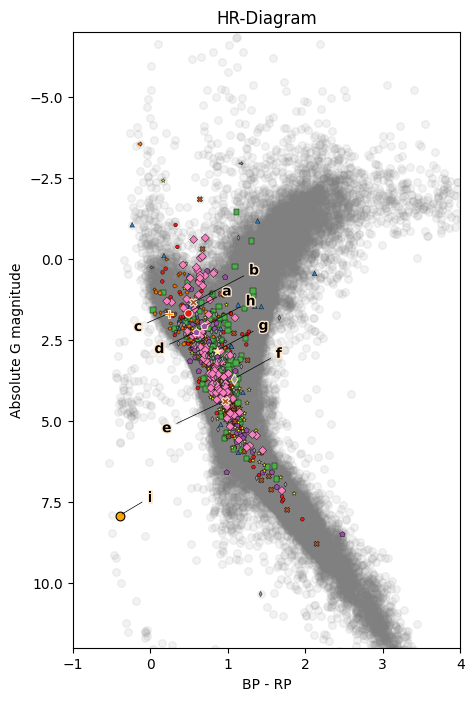

In [89]:
# --- run kmeans first as before ---
K = 9
kmeans = KMeans(n_clusters=K, init='k-means++', random_state=82)
kmeans.fit(log_squared_feats)
labels = kmeans.labels_
cluster_lookup = {int(s.strip()[3:]): lab for s, lab in zip(kics, labels)}
outlier_kic = 8490027
interesting_kics = np.array([3352751, 8166095, 6219684, 8145477, 9029486, 5218385, 1026032, 10229723])

# --- HR diagram ---
plt.figure(figsize=(5, 8))
plt.scatter(bp_rp_searched, abs_g_searched, s=30, color='gray', alpha=0.1, label='Searched stars')

# plot coherent oscillators colored by cluster
for group in range(K):
    sym = symbols[group % len(symbols)]
    size = sizes3[group % len(sizes3)]
    group_kics = np.array([kic for kic, lab in cluster_lookup.items() if lab == group])
    mask_group = np.isin(coherent_oscillators['kepid'], group_kics)
    plt.scatter(
        bp_rp_coherent[mask_group],
        abs_g_coherent[mask_group],
        c=[group] * mask_group.sum(),
        vmin=0, vmax=8,
        marker=sym,
        s=size,
        cmap='Set1',
        linewidths=0.3,
        edgecolors='black',
        zorder=4
    )

# special stars — force order to match interesting_kics
ordered_indices = [np.where(coherent_oscillators['kepid'] == kic)[0][0] 
                   for kic in interesting_kics if kic in coherent_oscillators['kepid']]
x_special = bp_rp_coherent[ordered_indices]
y_special = abs_g_coherent[ordered_indices]
special_kics = coherent_oscillators['kepid'][ordered_indices]
labels_abc = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']
offsets = [(25, 25/2), (40, 20), (-25, -25/2), (-30, -15), (-45, -45/2), (30, 15), (30, 15), (30, 15)]

for x, y, label, offset, kic in zip(x_special, y_special, labels_abc, offsets, special_kics):
    group = cluster_lookup.get(kic, 0)
    sym = symbols[group % len(symbols)]
    plt.scatter(x, y, c=[group], vmin=0, vmax=8, cmap='Set1',
                marker=sym, s=30,
                linewidths=0.8, edgecolors='bisque', zorder=5)
    plt.annotate(label, (x, y),
                 xytext=offset, textcoords='offset points',
                 fontsize=10, color='black', weight='bold', zorder=10,
                 path_effects=[pe.withStroke(linewidth=2, foreground='bisque')],
                 arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

# outlier star as orange dot
mask_outlier = coherent_oscillators['kepid'] == outlier_kic
plt.scatter(bp_rp_coherent[mask_outlier], abs_g_coherent[mask_outlier],
            s=40, color='orange', edgecolors='black', linewidths=0.8, zorder=6)
plt.annotate('i', (bp_rp_coherent[mask_outlier][0], abs_g_coherent[mask_outlier][0]),
             xytext=(20, 10), textcoords='offset points',
             fontsize=10, color='black', weight='bold', zorder=10,
             path_effects=[pe.withStroke(linewidth=2, foreground='bisque')],
             arrowprops=dict(arrowstyle='-', color='black', lw=0.5))

plt.gca().invert_yaxis()
plt.xlabel('BP - RP')
plt.ylabel('Absolute G magnitude')
plt.title('HR-Diagram')
plt.xlim(-1, 4)
plt.ylim(12, -7)
plt.savefig('hr_diagram_2026_06_08.png', bbox_inches='tight', dpi=150)
plt.show()

In [90]:
for kic in interesting_kics:
    found = kic in coherent_oscillators['kepid']
    print(kic, found)

3352751 True
8166095 True
6219684 True
8145477 True
9029486 True
5218385 True
1026032 True
10229723 True


In [91]:
for kic, label in zip(special_kics, labels_abc):
    idx = np.where(coherent_oscillators['kepid'] == kic)[0][0]
    print(label, kic, bp_rp_coherent[idx], abs_g_coherent[idx])

a 3352751 0.48042393 1.670360080520112
b 8166095 0.55690956 1.3454595101308158
c 6219684 0.23652649 1.691312842669488
d 8145477 0.59138775 2.2645310991924568
e 9029486 0.95853424 4.387044380068755
f 5218385 1.0814972 3.7003313690904136
g 1026032 0.85909176 2.835567072581693
h 10229723 0.69348145 2.0841500850498527
